# 03 – ARMA Order Selection

Selects the discrete ARMA(p, q) order for each residual series using AIC and a  
Ljung-Box whiteness gate. The selected orders are used **only** to generate  
starting values for the continuous-time CARMA MLE in notebook 05.

Inputs: `price_logresid_train.csv`, `temp_resid_train.csv`  
Outputs: printed summary; ARMA fits stored as `results/arma_selected.json`

In [1]:
import sys, os, json
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from config import TEMP_RESID_TRAIN_CSV, PRICE_RESID_TRAIN_CSV, RES_DIR

# Load training residuals
temp_df  = pd.read_csv(TEMP_RESID_TRAIN_CSV,  index_col=0, parse_dates=True)
price_df = pd.read_csv(PRICE_RESID_TRAIN_CSV, index_col=0, parse_dates=True)

temp_res  = temp_df.iloc[:, 0].dropna().to_numpy(dtype=float)
price_res = price_df.iloc[:, 0].dropna().to_numpy(dtype=float)

print(f'Temperature training obs : {len(temp_res):,}')
print(f'Log-price training obs   : {len(price_res):,}')

Temperature training obs : 43,825
Log-price training obs   : 17,521


## 1.  ACF / PACF of residuals

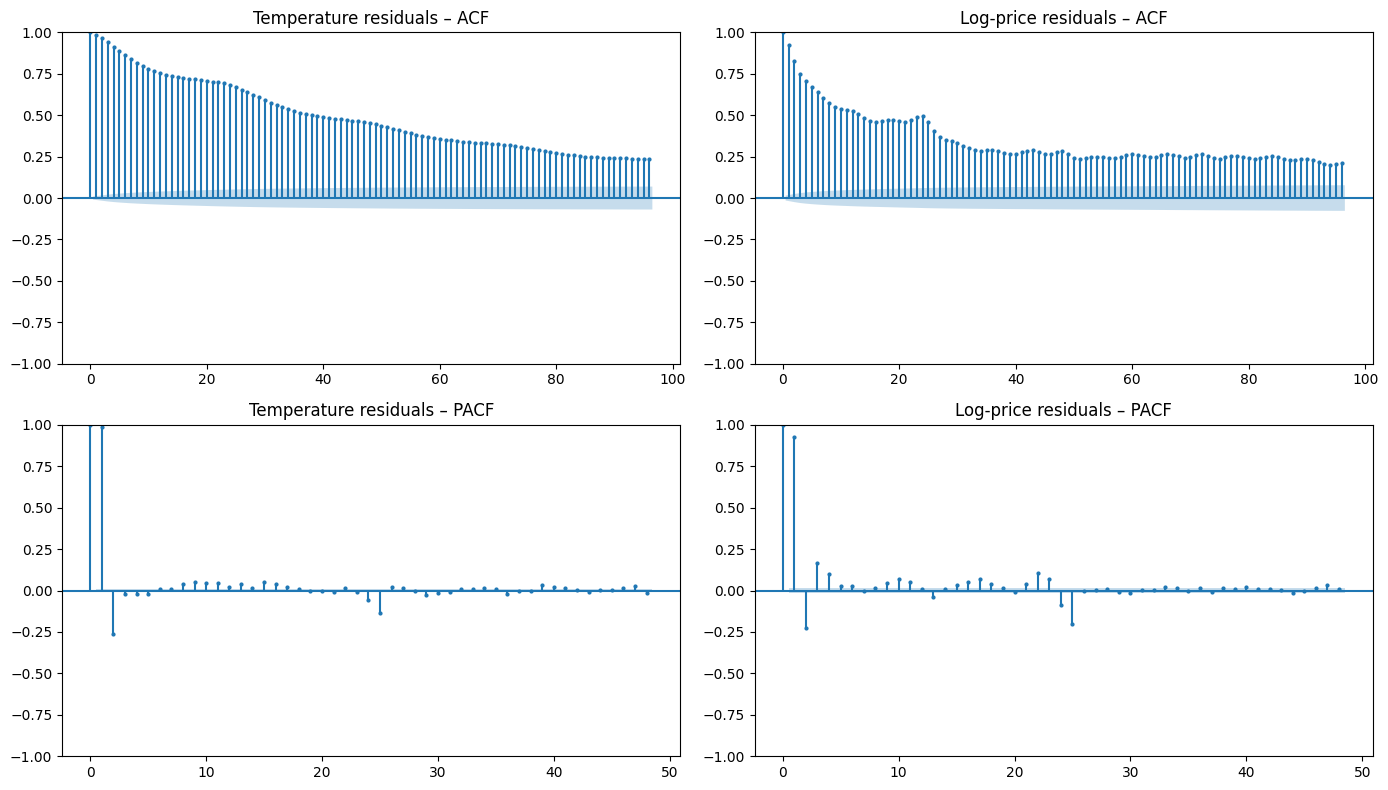

In [2]:
from config import FIG_DIR

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(temp_res,  lags=96, ax=axes[0, 0], markersize=2, title='Temperature residuals – ACF')
plot_pacf(temp_res, lags=48, ax=axes[1, 0], markersize=2, title='Temperature residuals – PACF')
plot_acf(price_res,  lags=96, ax=axes[0, 1], markersize=2, title='Log-price residuals – ACF')
plot_pacf(price_res, lags=48, ax=axes[1, 1], markersize=2, title='Log-price residuals – PACF')

plt.tight_layout()
plt.savefig(FIG_DIR / 'acf_pacf_residuals.png', dpi=150)
plt.show()

## 2.  AIC grid search over ARMA(p, q) candidates

In [3]:
def arma_grid(y, p_range, q_range, lb_lags=(24, 48)):
    '''
    Fit ARMA(p,q) models and return a DataFrame with AIC, BIC, and
    Ljung-Box p-values.
    '''
    records = []
    for p in p_range:
        for q in q_range:
            if p == 0 and q == 0:
                continue
            try:
                fit = ARIMA(y, order=(p, 0, q), trend='n').fit()
                lb  = acorr_ljungbox(fit.resid, lags=list(lb_lags), return_df=True)
                records.append({
                    'p': p, 'q': q,
                    'AIC': fit.aic,
                    'BIC': fit.bic,
                    'LB_24_pval': lb['lb_pvalue'].iloc[0],
                    'LB_48_pval': lb['lb_pvalue'].iloc[1],
                    'sigma2': fit.params[-1],
                })
            except Exception as e:
                records.append({'p': p, 'q': q, 'AIC': np.nan,
                                'BIC': np.nan, 'LB_24_pval': np.nan,
                                'LB_48_pval': np.nan, 'sigma2': np.nan})
    return pd.DataFrame(records).sort_values('AIC').reset_index(drop=True)


# Subsample every 6 obs for grid search speed (CARMA orders up to (3,2) need p<=3,q<=2)
temp_sub  = temp_res[::6]
price_sub = price_res[::6]
print(f'Grid search on {len(temp_sub):,} / {len(price_sub):,} subsampled obs')
print('Running ARMA grid for temperature …')
df_temp = arma_grid(temp_sub, range(1, 5), range(0, 4))
print('Running ARMA grid for log-price …')
df_price = arma_grid(price_sub, range(1, 5), range(0, 4))

print('\n── Temperature ──')
print(df_temp.round(2).to_string(index=False))
print('\n── Log-price ──')
print(df_price.round(2).to_string(index=False))

Grid search on 7,305 / 2,921 subsampled obs
Running ARMA grid for temperature …


/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Running ARMA grid for log-price …


/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



── Temperature ──
 p  q      AIC      BIC  LB_24_pval  LB_48_pval  sigma2
 4  3 29412.35 29467.52        0.04         0.0    3.27
 4  2 29503.90 29552.17        0.00         0.0    3.32
 3  3 29517.25 29565.52        0.00         0.0    3.32
 3  2 29560.50 29601.87        0.00         0.0    3.34
 4  1 29587.25 29628.63        0.00         0.0    3.36
 2  3 29725.78 29767.16        0.00         0.0    3.42
 4  0 29752.96 29787.44        0.00         0.0    3.43
 3  1 29800.52 29835.00        0.00         0.0    3.46
 3  0 29817.74 29845.33        0.00         0.0    3.46
 1  2 29856.98 29884.57        0.00         0.0    3.48
 1  3 29858.98 29893.47        0.00         0.0    3.48
 2  2 29858.98 29893.47        0.00         0.0    3.48
 1  1 29981.47 30002.15        0.00         0.0    3.54
 2  0 30015.17 30035.86        0.00         0.0    3.56
 2  1 30015.26 30042.85        0.00         0.0    3.56
 1  0 30067.76 30081.55        0.00         0.0    3.59

── Log-price ──
 p  q      A

## 3.  Select best model (lowest AIC passing LB gate at lag 24)

In [4]:
def select_model(df, lb_threshold=0.05):
    passing = df[df['LB_24_pval'] > lb_threshold]
    if len(passing) == 0:
        print('  WARNING: no model passes LB(24) – returning lowest AIC anyway.')
        passing = df
    best = passing.nsmallest(1, 'AIC').iloc[0]
    return int(best['p']), int(best['q']), best


p_temp,  q_temp,  row_temp  = select_model(df_temp)
p_price, q_price, row_price = select_model(df_price)

print(f'Selected temperature ARMA  :  ({p_temp}, {q_temp})')
print(f'  AIC={row_temp["AIC"]:.1f}   LB24_p={row_temp["LB_24_pval"]:.3f}   LB48_p={row_temp["LB_48_pval"]:.3f}')
print()
print(f'Selected log-price ARMA    :  ({p_price}, {q_price})')
print(f'  AIC={row_price["AIC"]:.1f}   LB24_p={row_price["LB_24_pval"]:.3f}   LB48_p={row_price["LB_48_pval"]:.3f}')

Selected temperature ARMA  :  (4, 3)
  AIC=29412.3   LB24_p=0.038   LB48_p=0.002

Selected log-price ARMA    :  (4, 2)
  AIC=-8776.9   LB24_p=0.000   LB48_p=0.000


## 4.  Fit and inspect the selected models

/home/sven/bin/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                43825
Model:                 ARIMA(4, 0, 3)   Log Likelihood              -40759.152
Date:                Mon, 30 Mar 2026   AIC                          81534.305
Time:                        14:25:29   BIC                          81603.809
Sample:                             0   HQIC                         81556.211
                              - 43825                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.4183      0.047     51.077      0.000       2.325       2.511
ar.L2         -2.5734      0.095    -27.199      0.000      -2.759      -2.388
ar.L3          1.4527      0.071     20.508      0.0

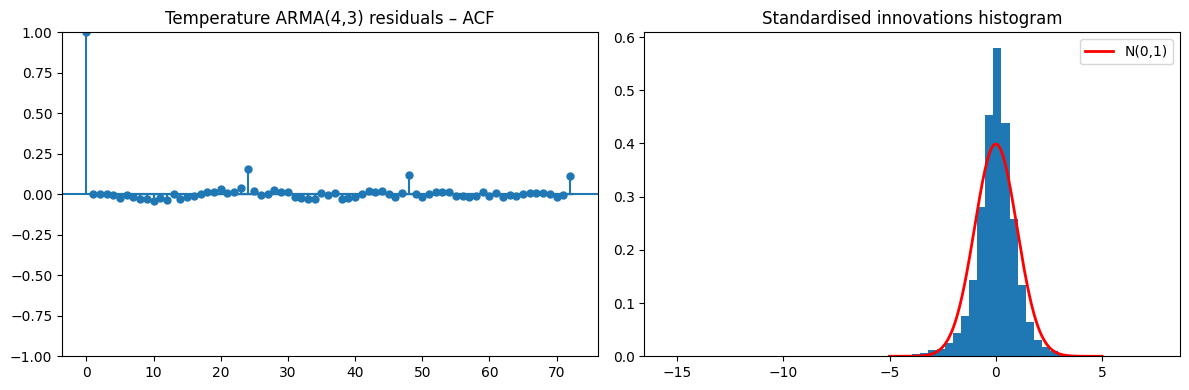

In [5]:
# ── Temperature ──────────────────────────────────────────────────────────────
fit_temp = ARIMA(temp_res, order=(p_temp, 0, q_temp), trend='n').fit()
print(fit_temp.summary())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(fit_temp.resid, lags=72, ax=axes[0],
         title=f'Temperature ARMA({p_temp},{q_temp}) residuals – ACF')
axes[1].hist(fit_temp.resid / fit_temp.resid.std(), bins=60, density=True)
xg = np.linspace(-5, 5, 200)
axes[1].plot(xg, 1/np.sqrt(2*np.pi)*np.exp(-xg**2/2), 'r-', lw=2, label='N(0,1)')
axes[1].set_title('Standardised innovations histogram')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'arma_temp_diagnostics.png', dpi=150)
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17521
Model:                 ARIMA(4, 0, 2)   Log Likelihood               40316.368
Date:                Mon, 30 Mar 2026   AIC                         -80618.736
Time:                        14:25:41   BIC                         -80564.338
Sample:                             0   HQIC                        -80600.824
                              - 17521                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9666      0.111      8.744      0.000       0.750       1.183
ar.L2          0.1161      0.198      0.585      0.558      -0.273       0.505
ar.L3         -0.3367      0.124     -2.712      0.0

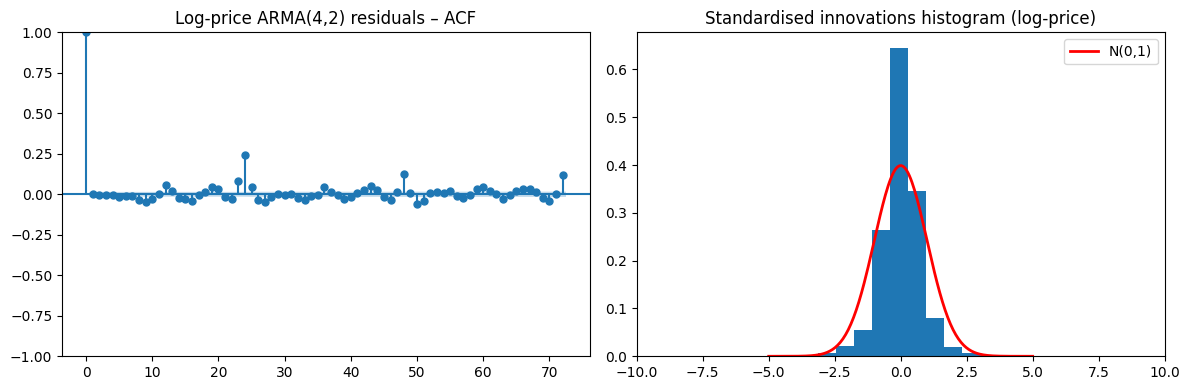

In [6]:
# ── Log-price ─────────────────────────────────────────────────────────────────
fit_price = ARIMA(price_res, order=(p_price, 0, q_price), trend='n').fit()
print(fit_price.summary())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(fit_price.resid, lags=72, ax=axes[0],
         title=f'Log-price ARMA({p_price},{q_price}) residuals – ACF')
axes[1].hist(fit_price.resid / fit_price.resid.std(), bins=100, density=True)
axes[1].plot(xg, 1/np.sqrt(2*np.pi)*np.exp(-xg**2/2), 'r-', lw=2, label='N(0,1)')
axes[1].set_xlim(-10, 10)
axes[1].set_title('Standardised innovations histogram (log-price)')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'arma_price_diagnostics.png', dpi=150)
plt.show()

## 5.  Save ARMA parameters for CARMA initialisation

In [7]:
def extract_arma_params(fit, p, q):
    'Extract AR and MA coefficients and sigma2 from a fitted ARIMA result.'
    params = fit.params
    # statsmodels ARIMA without trend: params = [ar.L1,...,ma.L1,...,sigma2]
    phi  = list(params[:p])
    theta = list(params[p:p+q]) if q > 0 else []
    s2   = float(params[-1])
    return {'phi': phi, 'theta': theta, 'sigma2': s2, 'p': p, 'q': q,
            'aic': float(fit.aic), 'bic': float(fit.bic)}

arma_selected = {
    'temperature': extract_arma_params(fit_temp,  p_temp,  q_temp),
    'logprice':    extract_arma_params(fit_price, p_price, q_price),
}

out_path = RES_DIR / 'arma_selected.json'
with open(out_path, 'w') as f:
    json.dump(arma_selected, f, indent=2)
print(f'Saved → {out_path}')
print(json.dumps(arma_selected, indent=2))

Saved → /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/notebooks/results/arma_selected.json
{
  "temperature": {
    "phi": [
      2.418257853316172,
      -2.573388951685253,
      1.452739378827859,
      -0.3089238804431369
    ],
    "theta": [
      -1.1846594395179253,
      0.8796890027380553,
      -0.09793016355995864
    ],
    "sigma2": 0.37586338751238674,
    "p": 4,
    "q": 3,
    "aic": 81534.30492235784,
    "bic": 81603.80860003615
  },
  "logprice": {
    "phi": [
      0.9666012372987807,
      0.11608684129071498,
      -0.33671078949081706,
      0.19556409721799972
    ],
    "theta": [
      0.1891096801041913,
      -0.2767445424343093
    ],
    "sigma2": 0.0005872428440190148,
    "p": 4,
    "q": 2,
    "aic": -80618.73649472541,
    "bic": -80564.338406642
  }
}
